In [2]:
import scanpy as sc
import pandas as pd
import anndata as ad
import harmonypy as hmå
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pilotpy.tools import *  #scvi env
from pilotpy.plot import *
import scanpy as sc

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import harmonypy as hm
import os
desired_path = '/beegfs//data/CostaLab/spatial_kidney_kuppelab/Adenin/HE/' # Or the folder your current notebook is in
os.chdir(desired_path)

In [33]:
adata=sc.read_h5ad('adenin_his.h5ad')
adata=adata[~adata.obs['leiden_02'].isin(['1','5','6','7','8','9','10','11','12',])].copy()
adata=adata[~adata.obs['leiden_03'].isin(['7'])].copy()

In [34]:
adata

AnnData object with n_obs × n_vars = 18682 × 1536
    obs: 'Slide_ID', 'Patch_ID_x', 'match_id', 'Sample_ID', 'X', 'Y', 'Patch_ID_y', 'leiden_01', 'leiden_02', 'leiden_03', 'leiden_04', 'leiden_05'
    uns: 'leiden_01', 'leiden_02', 'leiden_03', 'leiden_04', 'leiden_05', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

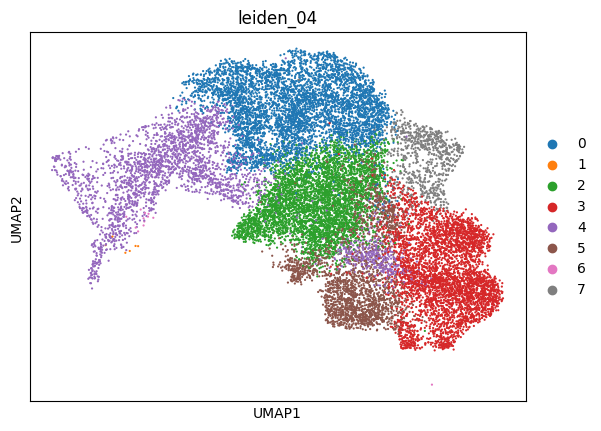

In [38]:
sc.pl.umap(adata, color=['leiden_04'], ncols=1,size=10)

Text(0.5, 1.0, 'UMAP with 10 Example Patches per Cluster')

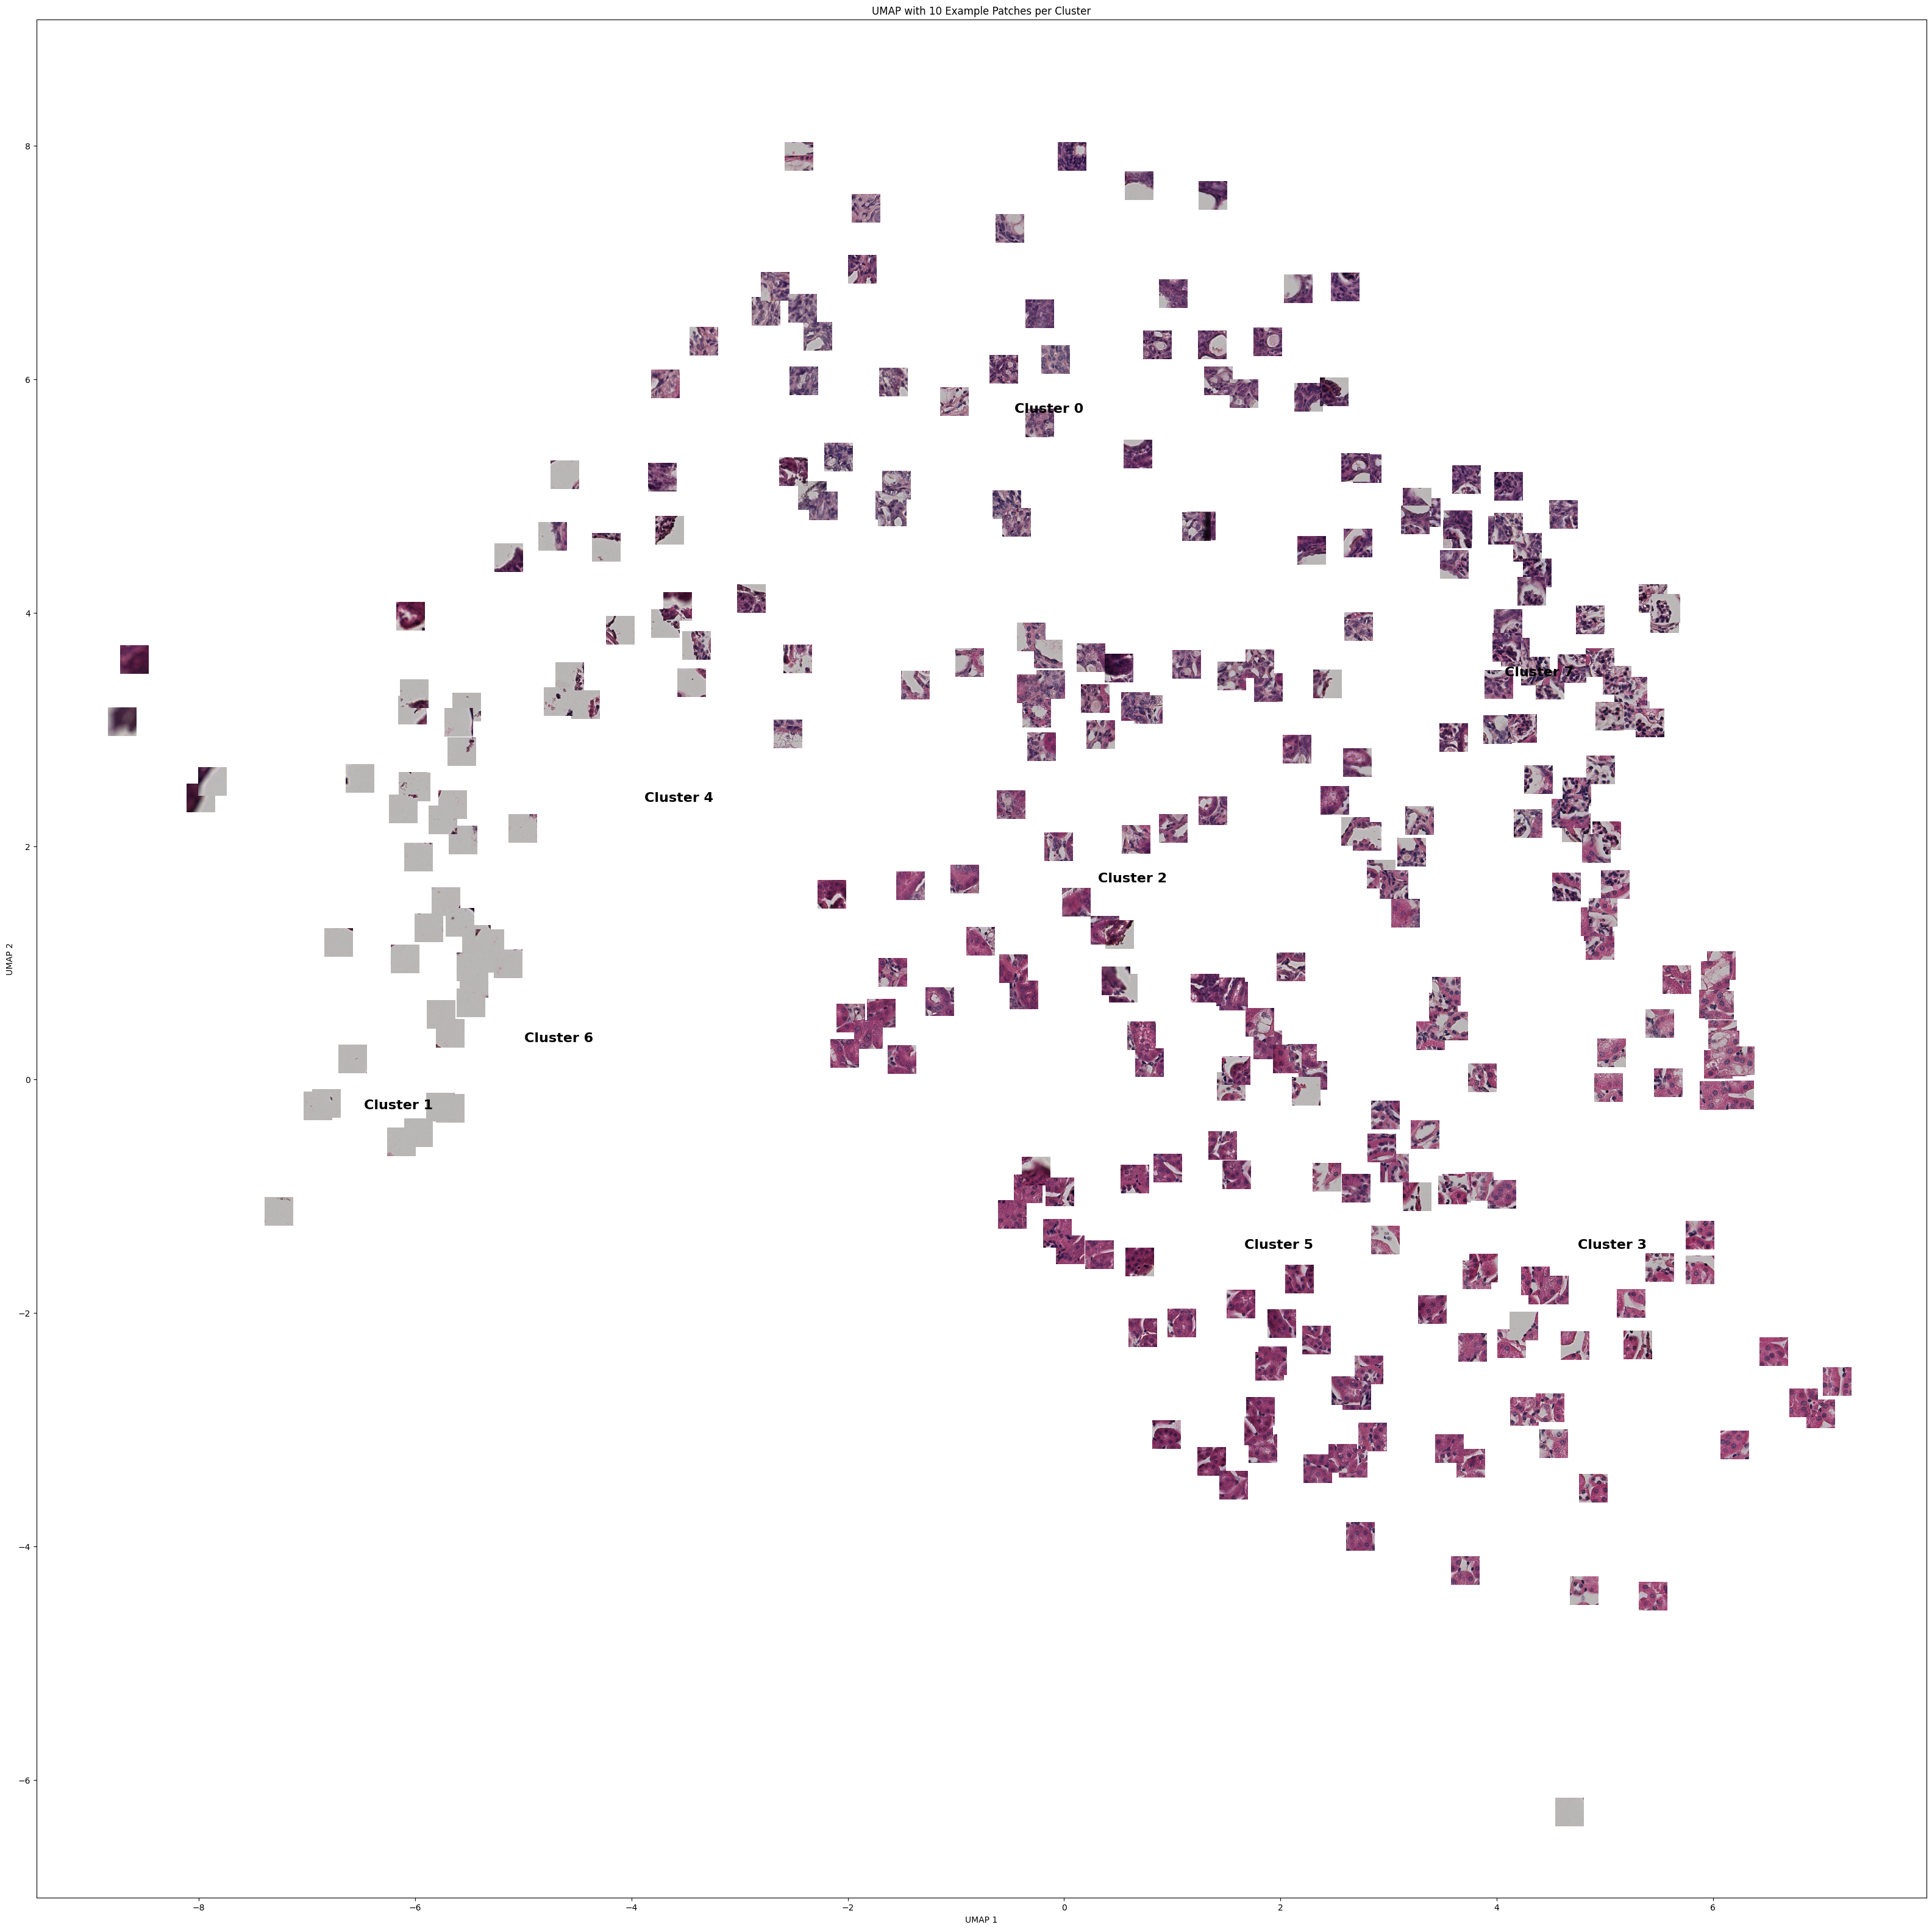

In [39]:
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import seaborn as sns
import random

# **Step 1: Extract UMAP Coordinates**
umap_coords = adata.obsm["X_umap"]
clusters = adata.obs["leiden_04"].astype(str)  # Convert Leiden clusters to strings
sample_ids = adata.obs["Slide_ID"].astype(str)  # Get patient/sample IDs
patch_ids = adata.obs["Patch_ID_x"].astype(str)  # Get patch file names

# **Step 2: Define Base Patch Folder**
patch_base_folder = "output_patches/"

# **Step 3: Function to Load Patch Images**
def getImage(path, zoom=0.15):  # Adjust zoom level for patch size
    return OffsetImage(plt.imread(path), zoom=zoom)

# **Step 4: Create UMAP Scatter Plot**
fig, ax = plt.subplots(figsize=(40, 40))
ax.scatter(umap_coords[:, 0], umap_coords[:, 1], c="white", alpha=1, edgecolors="w", label="Cells")

# **Step 5: Process Each Cluster**
for cluster in sorted(clusters.unique()):
    # **Select 10 Random Points for this Cluster**
    cluster_indices = np.where(clusters == cluster)[0]
    if len(cluster_indices) == 0:
        continue

    selected_indices = random.sample(list(cluster_indices), min(50, len(cluster_indices)))

    # **Step 6: Overlay Patch Images**
    for i in selected_indices:
        x0, y0 = umap_coords[i]  # Get UMAP position
        sample_id = sample_ids[i]  # Get Sample ID
        patch_id = patch_ids[i]  # Get Patch file name

        # **Construct Patch Path**
        patch_folder = os.path.join(patch_base_folder, sample_id)
        patch_path = os.path.join(patch_folder, patch_id)

        if not os.path.exists(patch_path):
            print(f"Warning: Missing patch {patch_path}")
            continue

        # **Step 7: Add Patch to UMAP**
        ab = AnnotationBbox(getImage(patch_path), (x0, y0), frameon=False, box_alignment=(0.5, 0.5), pad=0)
        ax.add_artist(ab)

    # **Step 8: Annotate Cluster**
    avg_x, avg_y = np.mean(umap_coords[cluster_indices], axis=0)
    ax.annotate(f"Cluster {cluster}", (avg_x, avg_y), fontsize=16, ha="center", color="black", weight="bold")

# **Step 9: Finalize & Show Plot**
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP with 10 Example Patches per Cluster")
#fig.savefig('Results_PILOT/Umap_patches.pdf')